# Notebook 4: Transfer Learning

This notebook develops pretrained computer-vision models for rice-disease classification.

Models:

- MobileNetV3-Small
- EfficientNet-B0

Their performance will be compared with the baseline CNN.

In [3]:
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:
# Mount google drive
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# Extract the dataset into Colab
!mkdir -p /content/Rice_Guard

!unzip -q \
"/content/drive/MyDrive/Rice_Guard/rice_guard_data.zip" \
-d "/content/Rice_Guard"

print("Dataset extracted.")

Dataset extracted.


In [6]:
# Find the zip in google drive
from pathlib import Path

zip_matches = list(
    Path("/content/drive/MyDrive").rglob("rice_guard_data.zip")
)

print("ZIP files found:", len(zip_matches))

for path in zip_matches:
    print(path)

ZIP files found: 1
/content/drive/MyDrive/Rice_Guard/rice_guard_data.zip


In [7]:
# Extract the zip
import zipfile
import shutil

ZIP_PATH = zip_matches[0]
EXTRACT_DIR = Path("/content/Rice_Guard")

# Remove an incomplete previous extraction
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
    zip_file.extractall(EXTRACT_DIR)

print("Extracted successfully to:", EXTRACT_DIR)

Extracted successfully to: /content/Rice_Guard


In [8]:
# Locate the files
train_image_matches = [
    path for path in EXTRACT_DIR.rglob("train_images")
    if path.is_dir()
]

train_csv_matches = list(
    EXTRACT_DIR.rglob("train_metadata.csv")
)

validation_csv_matches = list(
    EXTRACT_DIR.rglob("validation_metadata.csv")
)

test_csv_matches = list(
    EXTRACT_DIR.rglob("test_metadata.csv")
)

print("train_images folders:", train_image_matches)
print("train metadata:", train_csv_matches)
print("validation metadata:", validation_csv_matches)
print("test metadata:", test_csv_matches)

train_images folders: [PosixPath('/content/Rice_Guard/data - Copy/raw/train_images')]
train metadata: [PosixPath('/content/Rice_Guard/data - Copy/processed/train_metadata.csv')]
validation metadata: [PosixPath('/content/Rice_Guard/data - Copy/processed/validation_metadata.csv')]
test metadata: [PosixPath('/content/Rice_Guard/data - Copy/processed/test_metadata.csv')]


In [9]:
if not train_image_matches:
    raise FileNotFoundError("train_images was not found inside the ZIP.")

if not train_csv_matches:
    raise FileNotFoundError("train_metadata.csv was not found inside the ZIP.")

if not validation_csv_matches:
    raise FileNotFoundError(
        "validation_metadata.csv was not found inside the ZIP."
    )

if not test_csv_matches:
    raise FileNotFoundError("test_metadata.csv was not found inside the ZIP.")

TRAIN_IMAGE_DIR = train_image_matches[0]
TRAIN_CSV = train_csv_matches[0]
VALIDATION_CSV = validation_csv_matches[0]
TEST_CSV = test_csv_matches[0]

PROCESSED_DIR = TRAIN_CSV.parent

LABEL_MAPPING_PATH = PROCESSED_DIR / "label_mapping.json"
CLASS_WEIGHTS_PATH = PROCESSED_DIR / "class_weights.csv"

print("Training images:", TRAIN_IMAGE_DIR.exists())
print("Train metadata:", TRAIN_CSV.exists())
print("Validation metadata:", VALIDATION_CSV.exists())
print("Test metadata:", TEST_CSV.exists())
print("Label mapping:", LABEL_MAPPING_PATH.exists())
print("Class weights:", CLASS_WEIGHTS_PATH.exists())

Training images: True
Train metadata: True
Validation metadata: True
Test metadata: True
Label mapping: True
Class weights: True


In [10]:
# Load the metadata
import pandas as pd
import json
from pathlib import Path

train_df = pd.read_csv(TRAIN_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))

Training samples: 7284
Validation samples: 1561
Test samples: 1562


In [11]:
# Replace the windows image paths
for dataset_df in [train_df, validation_df, test_df]:
    dataset_df["image_path"] = dataset_df.apply(
        lambda row: (
            TRAIN_IMAGE_DIR
            / row["label"]
            / row["image_id"]
        ),
        axis=1
    )



In [12]:
for dataset_name, dataset_df in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}.items():

    images_found = dataset_df["image_path"].apply(
        lambda path: Path(path).exists()
    ).sum()

    print(
        f"{dataset_name}: "
        f"{images_found}/{len(dataset_df)} images found"
    )

Train: 7284/7284 images found
Validation: 1561/1561 images found
Test: 1562/1562 images found


In [13]:
# Load the label mapping and create the targets
with open(LABEL_MAPPING_PATH, "r", encoding="utf-8") as file:
    class_to_index = json.load(file)

index_to_class = {
    int(index): class_name
    for class_name, index in class_to_index.items()
}

class_names = [
    index_to_class[index]
    for index in sorted(index_to_class)
]

NUM_CLASSES = len(class_names)

for dataset_df in [train_df, validation_df, test_df]:
    dataset_df["target"] = (
        dataset_df["label"]
        .map(class_to_index)
        .astype(int)
    )

print("Number of classes:", NUM_CLASSES)
print("Missing training targets:", train_df["target"].isna().sum())
print("Missing validation targets:", validation_df["target"].isna().sum())
print("Missing test targets:", test_df["target"].isna().sum())

Number of classes: 10
Missing training targets: 0
Missing validation targets: 0
Missing test targets: 0


In [14]:
# imports and image settings
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGE_SIZE = 224
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [15]:
# Create image transformations
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [16]:
# Create the dataset class
class RiceDiseaseDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = Path(row["image_path"])
        target = int(row["target"])

        with Image.open(image_path) as image:
            image = image.convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

        return image, target

In [17]:
# Create dataset objects
train_dataset = RiceDiseaseDataset(
    dataframe=train_df,
    transform=train_transform
)

validation_dataset = RiceDiseaseDataset(
    dataframe=validation_df,
    transform=evaluation_transform
)

test_dataset = RiceDiseaseDataset(
    dataframe=test_df,
    transform=evaluation_transform
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

Training samples: 7284
Validation samples: 1561
Test samples: 1562


In [18]:
# Create the dataloaders
PIN_MEMORY = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=PIN_MEMORY
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN_MEMORY
)

In [19]:
# Verify everythings
print("Device:", DEVICE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

batch_images, batch_targets = next(iter(train_loader))

print("Image batch shape:", batch_images.shape)
print("Target batch shape:", batch_targets.shape)

Device: cuda
Training batches: 228
Validation batches: 49
Test batches: 49
Image batch shape: torch.Size([32, 3, 224, 224])
Target batch shape: torch.Size([32])


In [20]:
# Set folders for saved models
from pathlib import Path

DRIVE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/Rice_Guard"
)

MODEL_DIR = DRIVE_PROJECT_DIR / "models"
OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model folder:", MODEL_DIR)
print("Output folder:", OUTPUT_DIR)

Model folder: /content/drive/MyDrive/Rice_Guard/models
Output folder: /content/drive/MyDrive/Rice_Guard/outputs


In [21]:
# Create MobileNetV3-Small
import torch.nn as nn

from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

mobilenet_weights = MobileNet_V3_Small_Weights.DEFAULT

mobilenet_model = mobilenet_v3_small(
    weights=mobilenet_weights
)

print("MobileNetV3-Small loaded.")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 111MB/s]

MobileNetV3-Small loaded.


In [22]:
# Freeze features and replace the classifier
# Freeze pretrained feature layers
for parameter in mobilenet_model.features.parameters():
    parameter.requires_grad = False

# Replace the original classifier
input_features = mobilenet_model.classifier[-1].in_features

mobilenet_model.classifier[-1] = nn.Linear(
    input_features,
    NUM_CLASSES
)

mobilenet_model = mobilenet_model.to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in mobilenet_model.parameters()
    if parameter.requires_grad
)

print(mobilenet_model.classifier)
print(f"Trainable parameters: {trainable_parameters:,}")

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=10, bias=True)
)
Trainable parameters: 601,098


In [23]:
# Test it
mobilenet_model.eval()

sample_images = batch_images.to(DEVICE)

with torch.no_grad():
    sample_outputs = mobilenet_model(sample_images)

print("Output shape:", sample_outputs.shape)

Output shape: torch.Size([32, 10])


## Mobile net

In [24]:
# Load class weights and configure training
import pandas as pd
import time
import torch
import torch.nn as nn

class_weights_df = (
    pd.read_csv(CLASS_WEIGHTS_PATH)
    .sort_values("class_index")
)

class_weights_tensor = torch.tensor(
    class_weights_df["class_weight"].values,
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        mobilenet_model.parameters()
    ),
    lr=0.001,
    weight_decay=0.0001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("Training configuration is ready.")

Training configuration is ready.


In [25]:
# add the training and evaluation functions
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct_predictions += (
            predictions == targets
        ).sum().item()

        total_samples += targets.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

In [26]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct_predictions += (
                predictions == targets
            ).sum().item()

            total_samples += targets.size(0)

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return (
        epoch_loss,
        epoch_accuracy,
        all_targets,
        all_predictions
    )

In [27]:
# Define the training settings
NUM_EPOCHS = 5
PATIENCE = 2

MOBILENET_MODEL_PATH = (
    MODEL_DIR / "mobilenet_v3_small_stage1_best.pth"
)

print("Device:", DEVICE)
print("Maximum epochs:", NUM_EPOCHS)
print("Checkpoint path:", MOBILENET_MODEL_PATH)

Device: cuda
Maximum epochs: 5
Checkpoint path: /content/drive/MyDrive/Rice_Guard/models/mobilenet_v3_small_stage1_best.pth


In [28]:
# Train the MobileNet
mobilenet_history = {
    "train_loss": [],
    "validation_loss": [],
    "train_accuracy": [],
    "validation_accuracy": []
}

best_validation_loss = float("inf")
epochs_without_improvement = 0

training_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model=mobilenet_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    (
        validation_loss,
        validation_accuracy,
        _,
        _
    ) = evaluate_model(
        model=mobilenet_model,
        data_loader=validation_loader,
        criterion=criterion,
        device=DEVICE
    )

    scheduler.step(validation_loss)

    mobilenet_history["train_loss"].append(train_loss)
    mobilenet_history["validation_loss"].append(validation_loss)
    mobilenet_history["train_accuracy"].append(train_accuracy)
    mobilenet_history["validation_accuracy"].append(
        validation_accuracy
    )

    epoch_duration = time.time() - epoch_start_time

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Validation Loss: {validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_duration:.1f}s"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": mobilenet_model.state_dict(),
                "class_to_index": class_to_index,
                "image_size": IMAGE_SIZE,
                "epoch": epoch + 1,
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy
            },
            MOBILENET_MODEL_PATH
        )

        print("Best MobileNet checkpoint saved.")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

mobilenet_training_time = time.time() - training_start_time

print(
    f"\nTotal MobileNet Stage 1 training time: "
    f"{mobilenet_training_time / 60:.2f} minutes"
)

Epoch 1/5 | Train Loss: 1.7302 | Train Accuracy: 0.3981 | Validation Loss: 1.4628 | Validation Accuracy: 0.4952 | LR: 0.001000 | Time: 84.2s
Best MobileNet checkpoint saved.
Epoch 2/5 | Train Loss: 1.3377 | Train Accuracy: 0.5410 | Validation Loss: 1.2211 | Validation Accuracy: 0.5535 | LR: 0.001000 | Time: 84.8s
Best MobileNet checkpoint saved.
Epoch 3/5 | Train Loss: 1.1658 | Train Accuracy: 0.5994 | Validation Loss: 1.0036 | Validation Accuracy: 0.6650 | LR: 0.001000 | Time: 85.5s
Best MobileNet checkpoint saved.
Epoch 4/5 | Train Loss: 1.0603 | Train Accuracy: 0.6345 | Validation Loss: 0.8877 | Validation Accuracy: 0.6752 | LR: 0.001000 | Time: 85.0s
Best MobileNet checkpoint saved.
Epoch 5/5 | Train Loss: 0.9524 | Train Accuracy: 0.6649 | Validation Loss: 0.7970 | Validation Accuracy: 0.7181 | LR: 0.001000 | Time: 86.0s
Best MobileNet checkpoint saved.

Total MobileNet Stage 1 training time: 7.11 minutes


In [29]:
# Continue MobileNet training from epoch 6 to epoch 10

ADDITIONAL_EPOCHS = 5
PATIENCE = 3

best_validation_loss = min(
    mobilenet_history["validation_loss"]
)

epochs_without_improvement = 0
continuation_start_time = time.time()

for _ in range(ADDITIONAL_EPOCHS):
    epoch_number = len(
        mobilenet_history["train_loss"]
    ) + 1

    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model=mobilenet_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    (
        validation_loss,
        validation_accuracy,
        _,
        _
    ) = evaluate_model(
        model=mobilenet_model,
        data_loader=validation_loader,
        criterion=criterion,
        device=DEVICE
    )

    scheduler.step(validation_loss)

    mobilenet_history["train_loss"].append(train_loss)
    mobilenet_history["validation_loss"].append(validation_loss)
    mobilenet_history["train_accuracy"].append(train_accuracy)
    mobilenet_history["validation_accuracy"].append(
        validation_accuracy
    )

    epoch_duration = time.time() - epoch_start_time
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch_number}/10 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Validation Loss: {validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_duration:.1f}s"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": mobilenet_model.state_dict(),
                "class_to_index": class_to_index,
                "image_size": IMAGE_SIZE,
                "epoch": epoch_number,
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy
            },
            MOBILENET_MODEL_PATH
        )

        print("Best MobileNet checkpoint saved.")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

continuation_time = time.time() - continuation_start_time

print(
    f"\nAdditional training time: "
    f"{continuation_time / 60:.2f} minutes"
)

Epoch 6/10 | Train Loss: 0.9007 | Train Accuracy: 0.6825 | Validation Loss: 0.7754 | Validation Accuracy: 0.7463 | LR: 0.001000 | Time: 84.4s
Best MobileNet checkpoint saved.
Epoch 7/10 | Train Loss: 0.8364 | Train Accuracy: 0.7030 | Validation Loss: 0.7609 | Validation Accuracy: 0.7566 | LR: 0.001000 | Time: 85.7s
Best MobileNet checkpoint saved.
Epoch 8/10 | Train Loss: 0.7652 | Train Accuracy: 0.7249 | Validation Loss: 0.6982 | Validation Accuracy: 0.7694 | LR: 0.001000 | Time: 86.5s
Best MobileNet checkpoint saved.
Epoch 9/10 | Train Loss: 0.7665 | Train Accuracy: 0.7311 | Validation Loss: 0.7043 | Validation Accuracy: 0.7643 | LR: 0.001000 | Time: 86.7s
Epoch 10/10 | Train Loss: 0.7039 | Train Accuracy: 0.7504 | Validation Loss: 0.6373 | Validation Accuracy: 0.7783 | LR: 0.001000 | Time: 84.9s
Best MobileNet checkpoint saved.

Additional training time: 7.14 minutes


In [30]:
# Save the MobileNet training history
mobilenet_history_df = pd.DataFrame(mobilenet_history)
mobilenet_history_df.index = range(1, len(mobilenet_history_df) + 1)
mobilenet_history_df.index.name = "epoch"

MOBILENET_HISTORY_PATH = (
    OUTPUT_DIR / "mobilenet_training_history.csv"
)

mobilenet_history_df.to_csv(MOBILENET_HISTORY_PATH)

display(mobilenet_history_df.round(4))

,train_loss,validation_loss,train_accuracy,validation_accuracy
epoch,,,,
1,1.7302,1.4628,0.3981,0.4952
2,1.3377,1.2211,0.5410,0.5535
3,1.1658,1.0036,0.5994,0.6650
4,1.0603,0.8877,0.6345,0.6752
5,0.9524,0.7970,0.6649,0.7181
6,0.9007,0.7754,0.6825,0.7463
7,0.8364,0.7609,0.7030,0.7566
8,0.7652,0.6982,0.7249,0.7694
9,0.7665,0.7043,0.7311,0.7643


In [31]:
# Load the best checkpoint
checkpoint = torch.load(
    MOBILENET_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

mobilenet_model.load_state_dict(
    checkpoint["model_state_dict"]
)

mobilenet_model = mobilenet_model.to(DEVICE)
mobilenet_model.eval()

print("Best epoch:", checkpoint["epoch"])
print(
    "Best validation loss:",
    round(checkpoint["validation_loss"], 4)
)
print(
    "Best validation accuracy:",
    round(checkpoint["validation_accuracy"], 4)
)

Best epoch: 10
Best validation loss: 0.6373
Best validation accuracy: 0.7783


In [32]:
# Evaluate on the internal test set
(
    mobilenet_test_loss,
    mobilenet_test_accuracy,
    mobilenet_test_targets,
    mobilenet_test_predictions
) = evaluate_model(
    model=mobilenet_model,
    data_loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

print(f"MobileNet test loss: {mobilenet_test_loss:.4f}")
print(f"MobileNet test accuracy: {mobilenet_test_accuracy:.4f}")

MobileNet test loss: 0.5967
MobileNet test accuracy: 0.7817


In [33]:
# Create and save the classification report
from sklearn.metrics import classification_report

display_names = [
    class_name.replace("_", " ").title()
    for class_name in class_names
]

mobilenet_report = classification_report(
    mobilenet_test_targets,
    mobilenet_test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=display_names,
    output_dict=True,
    zero_division=0
)

mobilenet_report_df = pd.DataFrame(
    mobilenet_report
).transpose()

display(mobilenet_report_df.round(4))

MOBILENET_REPORT_PATH = (
    OUTPUT_DIR / "mobilenet_classification_report.csv"
)

mobilenet_report_df.to_csv(MOBILENET_REPORT_PATH)

,precision,recall,f1-score,support
Bacterial Leaf Blight,0.4646,0.8194,0.5930,72.0000
Bacterial Leaf Streak,0.7647,0.9123,0.8320,57.0000
Bacterial Panicle Blight,0.8600,0.8600,0.8600,50.0000
Blast,0.8957,0.7241,0.8008,261.0000
Brown Spot,0.8051,0.6552,0.7224,145.0000
Dead Heart,0.9135,0.8756,0.8941,217.0000
Downy Mildew,0.7009,0.8065,0.7500,93.0000
Hispa,0.7664,0.6862,0.7241,239.0000
Normal,0.8244,0.8679,0.8456,265.0000
Tungro,0.6889,0.7607,0.7230,163.0000


In [34]:
# Save the concise metrics
mobilenet_metrics_df = pd.DataFrame([
    {
        "model": "MobileNetV3-Small",
        "best_epoch": checkpoint["epoch"],
        "validation_accuracy": checkpoint[
            "validation_accuracy"
        ],
        "test_loss": mobilenet_test_loss,
        "test_accuracy": mobilenet_test_accuracy,
        "macro_precision": mobilenet_report[
            "macro avg"
        ]["precision"],
        "macro_recall": mobilenet_report[
            "macro avg"
        ]["recall"],
        "macro_f1": mobilenet_report[
            "macro avg"
        ]["f1-score"],
        "weighted_f1": mobilenet_report[
            "weighted avg"
        ]["f1-score"]
    }
])

MOBILENET_METRICS_PATH = (
    OUTPUT_DIR / "mobilenet_metrics.csv"
)

mobilenet_metrics_df.to_csv(
    MOBILENET_METRICS_PATH,
    index=False
)

display(mobilenet_metrics_df.round(4))

,model,best_epoch,validation_accuracy,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,MobileNetV3-Small,10,0.7783,0.5967,0.7817,0.7684,0.7968,0.7745,0.7847


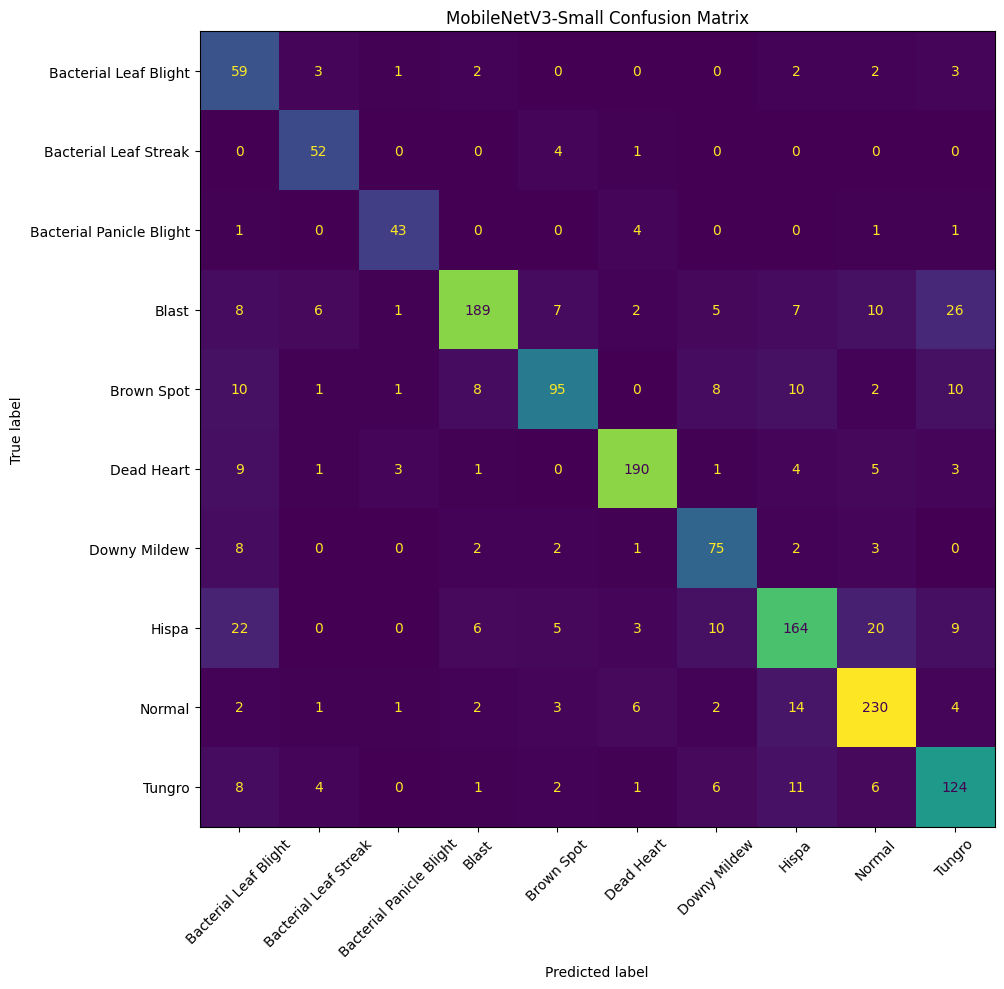

In [35]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mobilenet_cm = confusion_matrix(
    mobilenet_test_targets,
    mobilenet_test_predictions,
    labels=list(range(NUM_CLASSES))
)

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay(
    confusion_matrix=mobilenet_cm,
    display_labels=display_names
).plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
    colorbar=False
)

plt.title("MobileNetV3-Small Confusion Matrix")
plt.tight_layout()
plt.show()

In [36]:
# Save individual test predictions
mobilenet_results_df = test_df[
    ["image_id", "image_path", "label"]
].reset_index(drop=True).copy()

mobilenet_results_df["true_target"] = mobilenet_test_targets
mobilenet_results_df["predicted_target"] = mobilenet_test_predictions

mobilenet_results_df["predicted_label"] = [
    index_to_class[int(prediction)]
    for prediction in mobilenet_test_predictions
]

mobilenet_results_df["correct_prediction"] = (
    mobilenet_results_df["label"]
    == mobilenet_results_df["predicted_label"]
)

MOBILENET_PREDICTIONS_PATH = (
    OUTPUT_DIR / "mobilenet_test_predictions.csv"
)

mobilenet_results_df.to_csv(
    MOBILENET_PREDICTIONS_PATH,
    index=False
)

display(mobilenet_results_df.head())

print("Predictions saved to:")
print(MOBILENET_PREDICTIONS_PATH)

,image_id,image_path,label,true_target,predicted_target,predicted_label,correct_prediction
0,101970.jpg,/content/Rice_Guard/data - Copy/raw/train_imag...,dead_heart,5,5,dead_heart,True
1,105763.jpg,/content/Rice_Guard/data - Copy/raw/train_imag...,brown_spot,4,4,brown_spot,True
2,106689.jpg,/content/Rice_Guard/data - Copy/raw/train_imag...,tungro,9,9,tungro,True
3,103812.jpg,/content/Rice_Guard/data - Copy/raw/train_imag...,blast,3,7,hispa,False
4,100597.jpg,/content/Rice_Guard/data - Copy/raw/train_imag...,blast,3,9,tungro,False


Predictions saved to:
/content/drive/MyDrive/Rice_Guard/outputs/mobilenet_test_predictions.csv


Incorrect predictions: 341


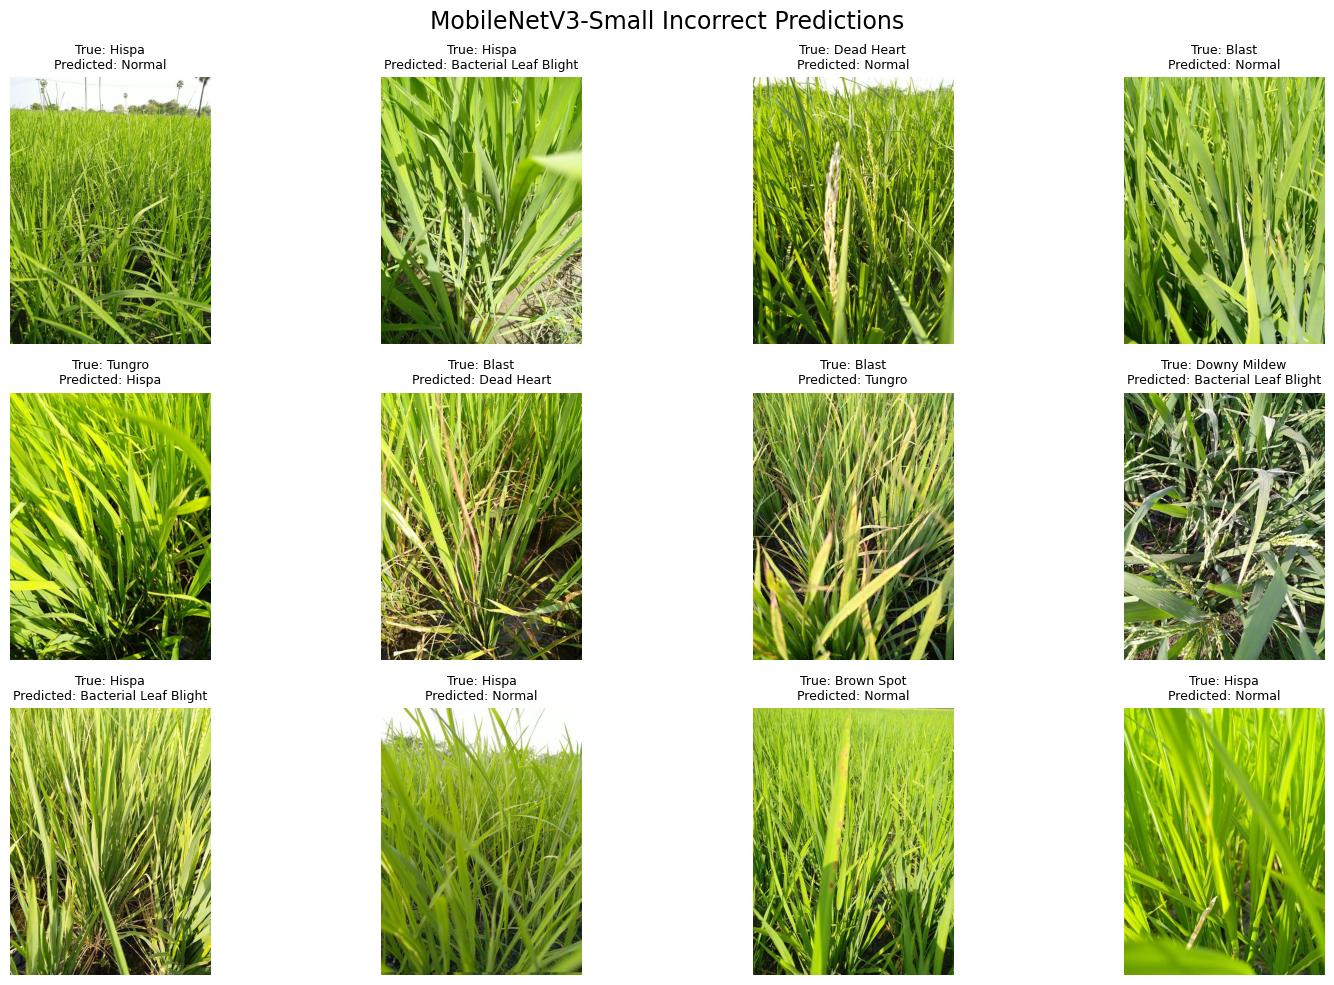

In [37]:
# Display incorrect predictions
from PIL import Image

mobilenet_incorrect_df = mobilenet_results_df[
    ~mobilenet_results_df["correct_prediction"]
].copy()

print(
    "Incorrect predictions:",
    len(mobilenet_incorrect_df)
)

number_to_display = min(
    12,
    len(mobilenet_incorrect_df)
)

if number_to_display > 0:
    samples = mobilenet_incorrect_df.sample(
        n=number_to_display,
        random_state=42
    )

    plt.figure(figsize=(16, 10))

    for index, (_, row) in enumerate(samples.iterrows()):
        with Image.open(row["image_path"]) as image:
            plt.subplot(3, 4, index + 1)
            plt.imshow(image.convert("RGB"))

        true_label = (
            row["label"]
            .replace("_", " ")
            .title()
        )

        predicted_label = (
            row["predicted_label"]
            .replace("_", " ")
            .title()
        )

        plt.title(
            f"True: {true_label}\n"
            f"Predicted: {predicted_label}",
            fontsize=9
        )

        plt.axis("off")

    plt.suptitle(
        "MobileNetV3-Small Incorrect Predictions",
        fontsize=17
    )

    plt.tight_layout()
    plt.show()

## MobileNetV3-Small Conclusion

MobileNetV3-Small achieved:

- Best epoch: 8
- Best validation accuracy: 79.95%
- Best validation loss: 0.6136
- Test accuracy: **[insert result]**
- Macro F1-score: **[insert result]**

MobileNet substantially outperformed the baseline CNN while remaining lightweight and efficient. The next model will be EfficientNet-B0.

# Part 2: EfficientNet-B0 Transfer Learning

This section trains EfficientNet-B0 pretrained on ImageNet and compares its performance with MobileNetV3-Small and the baseline CNN.

In [38]:
# Import EfficientNet-B0
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

In [39]:
# Create the pretrained model
efficientnet_weights = EfficientNet_B0_Weights.DEFAULT

efficientnet_model = efficientnet_b0(
    weights=efficientnet_weights
)

print("EfficientNet-B0 loaded successfully.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 116MB/s] 


EfficientNet-B0 loaded successfully.


In [40]:
# freeze the feature extractor
for parameter in efficientnet_model.features.parameters() :
  parameter.requires_grad = False
print("EfficientNet feature layers are frozen")

EfficientNet feature layers are frozen


In [41]:
# Replace the classifier
input_features = efficientnet_model.classifier[-1].in_features

efficientnet_model.classifier[-1] = nn.Linear(
    input_features,
    NUM_CLASSES
)

efficientnet_model = efficientnet_model.to(DEVICE)

print(efficientnet_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


In [42]:
# Count trainable parameters
total_parameters = sum(
    parameter.numel()
    for parameter in efficientnet_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in efficientnet_model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters: 4,020,358
Trainable parameters: 12,810


In [43]:
# Test one batch
efficientnet_model.eval()
sample_images = batch_images.to(DEVICE)
with torch.no_grad():
  sample_outputs = efficientnet_model(sample_images)
print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 10])


In [44]:
# Create EfficientNet optimizer and scheduler
efficientnet_optimizer = torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        efficientnet_model.parameters()
    ),
    lr=0.001,
    weight_decay=0.0001
)

efficientnet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    efficientnet_optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("EfficientNet optimizer and scheduler are ready.")

EfficientNet optimizer and scheduler are ready.


In [45]:
# Define training settings
EFFICIENTNET_EPOCHS = 5
EFFICIENTNET_PATIENCE = 2

EFFICIENTNET_MODEL_PATH = (
    MODEL_DIR / "efficientnet_b0_best.pth"
)

print("Maximum epochs:", EFFICIENTNET_EPOCHS)
print("Checkpoint path:", EFFICIENTNET_MODEL_PATH)

Maximum epochs: 5
Checkpoint path: /content/drive/MyDrive/Rice_Guard/models/efficientnet_b0_best.pth


In [46]:
# Train EfficientNet-B0
efficientnet_history = {
    "train_loss": [],
    "validation_loss": [],
    "train_accuracy": [],
    "validation_accuracy": []
}

best_validation_loss = float("inf")
epochs_without_improvement = 0

efficientnet_start_time = time.time()

for epoch in range(EFFICIENTNET_EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model=efficientnet_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=efficientnet_optimizer,
        device=DEVICE
    )

    (
        validation_loss,
        validation_accuracy,
        _,
        _
    ) = evaluate_model(
        model=efficientnet_model,
        data_loader=validation_loader,
        criterion=criterion,
        device=DEVICE
    )

    efficientnet_scheduler.step(validation_loss)

    efficientnet_history["train_loss"].append(train_loss)
    efficientnet_history["validation_loss"].append(validation_loss)
    efficientnet_history["train_accuracy"].append(train_accuracy)
    efficientnet_history["validation_accuracy"].append(
        validation_accuracy
    )

    epoch_duration = time.time() - epoch_start_time
    current_lr = efficientnet_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1}/{EFFICIENTNET_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Validation Loss: {validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_duration:.1f}s"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": efficientnet_model.state_dict(),
                "class_to_index": class_to_index,
                "image_size": IMAGE_SIZE,
                "epoch": epoch + 1,
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy
            },
            EFFICIENTNET_MODEL_PATH
        )

        print("Best EfficientNet checkpoint saved.")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EFFICIENTNET_PATIENCE:
        print("Early stopping triggered.")
        break

efficientnet_training_time = (
    time.time() - efficientnet_start_time
)

print(
    f"\nTotal EfficientNet training time: "
    f"{efficientnet_training_time / 60:.2f} minutes"
)

Epoch 1/5 | Train Loss: 1.8823 | Train Accuracy: 0.3715 | Validation Loss: 1.6265 | Validation Accuracy: 0.4446 | LR: 0.001000 | Time: 88.8s
Best EfficientNet checkpoint saved.
Epoch 2/5 | Train Loss: 1.5655 | Train Accuracy: 0.4654 | Validation Loss: 1.4435 | Validation Accuracy: 0.5298 | LR: 0.001000 | Time: 89.2s
Best EfficientNet checkpoint saved.
Epoch 3/5 | Train Loss: 1.4512 | Train Accuracy: 0.5043 | Validation Loss: 1.3182 | Validation Accuracy: 0.5778 | LR: 0.001000 | Time: 87.3s
Best EfficientNet checkpoint saved.
Epoch 4/5 | Train Loss: 1.3941 | Train Accuracy: 0.5144 | Validation Loss: 1.2747 | Validation Accuracy: 0.5881 | LR: 0.001000 | Time: 86.9s
Best EfficientNet checkpoint saved.
Epoch 5/5 | Train Loss: 1.3479 | Train Accuracy: 0.5332 | Validation Loss: 1.2372 | Validation Accuracy: 0.6105 | LR: 0.001000 | Time: 86.4s
Best EfficientNet checkpoint saved.

Total EfficientNet training time: 7.35 minutes


In [47]:
# Continue EfficientNet training from epoch 6 to epoch 10

ADDITIONAL_EPOCHS = 5
PATIENCE = 3

best_validation_loss = min(
    efficientnet_history["validation_loss"]
)

epochs_without_improvement = 0
continuation_start_time = time.time()

for _ in range(ADDITIONAL_EPOCHS):
    epoch_number = len(
        efficientnet_history["train_loss"]
    ) + 1

    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model=efficientnet_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=efficientnet_optimizer,
        device=DEVICE
    )

    (
        validation_loss,
        validation_accuracy,
        _,
        _
    ) = evaluate_model(
        model=efficientnet_model,
        data_loader=validation_loader,
        criterion=criterion,
        device=DEVICE
    )

    efficientnet_scheduler.step(validation_loss)

    efficientnet_history["train_loss"].append(train_loss)
    efficientnet_history["validation_loss"].append(validation_loss)
    efficientnet_history["train_accuracy"].append(train_accuracy)
    efficientnet_history["validation_accuracy"].append(
        validation_accuracy
    )

    epoch_duration = time.time() - epoch_start_time
    current_lr = efficientnet_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch_number}/10 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Validation Loss: {validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_duration:.1f}s"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": efficientnet_model.state_dict(),
                "class_to_index": class_to_index,
                "image_size": IMAGE_SIZE,
                "epoch": epoch_number,
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy
            },
            EFFICIENTNET_MODEL_PATH
        )

        print("Best EfficientNet checkpoint saved.")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

additional_training_time = (
    time.time() - continuation_start_time
)

print(
    f"\nAdditional EfficientNet training time: "
    f"{additional_training_time / 60:.2f} minutes"
)

Epoch 6/10 | Train Loss: 1.3248 | Train Accuracy: 0.5472 | Validation Loss: 1.1787 | Validation Accuracy: 0.6182 | LR: 0.001000 | Time: 86.6s
Best EfficientNet checkpoint saved.
Epoch 7/10 | Train Loss: 1.3043 | Train Accuracy: 0.5474 | Validation Loss: 1.1418 | Validation Accuracy: 0.6387 | LR: 0.001000 | Time: 85.3s
Best EfficientNet checkpoint saved.
Epoch 8/10 | Train Loss: 1.2706 | Train Accuracy: 0.5603 | Validation Loss: 1.1619 | Validation Accuracy: 0.6131 | LR: 0.001000 | Time: 86.8s
Epoch 9/10 | Train Loss: 1.2599 | Train Accuracy: 0.5611 | Validation Loss: 1.1120 | Validation Accuracy: 0.6272 | LR: 0.001000 | Time: 87.4s
Best EfficientNet checkpoint saved.
Epoch 10/10 | Train Loss: 1.2730 | Train Accuracy: 0.5623 | Validation Loss: 1.1230 | Validation Accuracy: 0.6233 | LR: 0.001000 | Time: 88.0s

Additional EfficientNet training time: 7.24 minutes


In [48]:
# Save the training history
efficientnet_history_df = pd.DataFrame(efficientnet_history)

efficientnet_history_df.index = range(
    1,
    len(efficientnet_history_df) + 1
)
efficientnet_history_df.index.name = "epoch"

EFFICIENTNET_HISTORY_PATH = (
    OUTPUT_DIR / "efficientnet_training_history.csv"
)

efficientnet_history_df.to_csv(
    EFFICIENTNET_HISTORY_PATH
)

display(efficientnet_history_df.round(4))

,train_loss,validation_loss,train_accuracy,validation_accuracy
epoch,,,,
1,1.8823,1.6265,0.3715,0.4446
2,1.5655,1.4435,0.4654,0.5298
3,1.4512,1.3182,0.5043,0.5778
4,1.3941,1.2747,0.5144,0.5881
5,1.3479,1.2372,0.5332,0.6105
6,1.3248,1.1787,0.5472,0.6182
7,1.3043,1.1418,0.5474,0.6387
8,1.2706,1.1619,0.5603,0.6131
9,1.2599,1.1120,0.5611,0.6272


In [49]:
# Load the best EfficientNet checkpoint
checkpoint = torch.load(
    EFFICIENTNET_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

efficientnet_model.load_state_dict(
    checkpoint["model_state_dict"]
)

efficientnet_model = efficientnet_model.to(DEVICE)
efficientnet_model.eval()

print("Best checkpoint epoch:", checkpoint["epoch"])
print(
    "Best validation loss:",
    round(checkpoint["validation_loss"], 4)
)
print(
    "Validation accuracy at checkpoint:",
    round(checkpoint["validation_accuracy"], 4)
)

Best checkpoint epoch: 9
Best validation loss: 1.112
Validation accuracy at checkpoint: 0.6272


In [50]:
# Evaluate on the internal test set
(
    efficientnet_test_loss,
    efficientnet_test_accuracy,
    efficientnet_test_targets,
    efficientnet_test_predictions
) = evaluate_model(
    model=efficientnet_model,
    data_loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

print(
    f"EfficientNet test loss: "
    f"{efficientnet_test_loss:.4f}"
)

print(
    f"EfficientNet test accuracy: "
    f"{efficientnet_test_accuracy:.4f}"
)

EfficientNet test loss: 1.0603
EfficientNet test accuracy: 0.6293


In [51]:
# create and save the classification report
from sklearn.metrics import classification_report

efficientnet_report = classification_report(
    efficientnet_test_targets,
    efficientnet_test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=display_names,
    output_dict=True,
    zero_division=0
)

efficientnet_report_df = pd.DataFrame(
    efficientnet_report
).transpose()

display(efficientnet_report_df.round(4))

EFFICIENTNET_REPORT_PATH = (
    OUTPUT_DIR / "efficientnet_classification_report.csv"
)

efficientnet_report_df.to_csv(
    EFFICIENTNET_REPORT_PATH
)

,precision,recall,f1-score,support
Bacterial Leaf Blight,0.3359,0.6111,0.4335,72.0000
Bacterial Leaf Streak,0.5053,0.8421,0.6316,57.0000
Bacterial Panicle Blight,0.5974,0.9200,0.7244,50.0000
Blast,0.6734,0.6398,0.6562,261.0000
Brown Spot,0.6316,0.4138,0.5000,145.0000
Dead Heart,0.8111,0.6728,0.7355,217.0000
Downy Mildew,0.4233,0.7419,0.5391,93.0000
Hispa,0.7672,0.3724,0.5014,239.0000
Normal,0.7422,0.8038,0.7717,265.0000
Tungro,0.5941,0.6196,0.6066,163.0000


In [52]:
# Save the concise metrics
efficientnet_metrics_df = pd.DataFrame([
    {
        "model": "EfficientNet-B0",
        "best_epoch": checkpoint["epoch"],
        "validation_accuracy": checkpoint[
            "validation_accuracy"
        ],
        "test_loss": efficientnet_test_loss,
        "test_accuracy": efficientnet_test_accuracy,
        "macro_precision": efficientnet_report[
            "macro avg"
        ]["precision"],
        "macro_recall": efficientnet_report[
            "macro avg"
        ]["recall"],
        "macro_f1": efficientnet_report[
            "macro avg"
        ]["f1-score"],
        "weighted_f1": efficientnet_report[
            "weighted avg"
        ]["f1-score"],
        "training_minutes": 7.98 + 7.24
    }
])

EFFICIENTNET_METRICS_PATH = (
    OUTPUT_DIR / "efficientnet_metrics.csv"
)

efficientnet_metrics_df.to_csv(
    EFFICIENTNET_METRICS_PATH,
    index=False
)

display(efficientnet_metrics_df.round(4))

,model,best_epoch,validation_accuracy,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_minutes
0,EfficientNet-B0,9,0.6272,1.0603,0.6293,0.6081,0.6637,0.61,0.6275,15.22


In [54]:
# Model comparison
model_comparison_df = pd.DataFrame([
    {
        "model": "Baseline CNN",
        "best_epoch": 10,
        "validation_accuracy": 0.5727,
        "test_loss": 1.2682,
        "test_accuracy": 0.5813,
        "macro_precision": 0.5734,
        "macro_recall": 0.5738,
        "macro_f1": 0.5533,
        "weighted_f1": 0.5696,
        "training_minutes": 74.3009
    },
    {
        "model": "MobileNetV3-Small",
        "best_epoch": 10,
        "validation_accuracy": 0.7783,
        "test_loss": 0.5967,
        "test_accuracy": 0.7817,
        "macro_precision": 0.7684,
        "macro_recall": 0.7968,
        "macro_f1": 0.7745,
        "weighted_f1": 0.7847,
        "training_minutes": 14.27
    },
    {
        "model": "EfficientNet-B0",
        "best_epoch": 9,
        "validation_accuracy": 0.6272,
        "test_loss": 1.0603,
        "test_accuracy": 0.6293,
        "macro_precision": 0.6081,
        "macro_recall": 0.6637,
        "macro_f1": 0.6100,
        "weighted_f1": 0.6275,
        "training_minutes": 15.22
    }
])

model_comparison_df = model_comparison_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

display(model_comparison_df.round(4))

,model,best_epoch,validation_accuracy,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_minutes
0,MobileNetV3-Small,10,0.7783,0.5967,0.7817,0.7684,0.7968,0.7745,0.7847,14.2700
1,EfficientNet-B0,9,0.6272,1.0603,0.6293,0.6081,0.6637,0.6100,0.6275,15.2200
2,Baseline CNN,10,0.5727,1.2682,0.5813,0.5734,0.5738,0.5533,0.5696,74.3009


In [55]:
# Save
MODEL_COMPARISON_PATH = OUTPUT_DIR / "model_comparison.csv"

model_comparison_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)

print("Comparison saved to:")
print(MODEL_COMPARISON_PATH)


Comparison saved to:
/content/drive/MyDrive/Rice_Guard/outputs/model_comparison.csv


# Final Model Comparison

Three image-classification models were evaluated for rice-disease recognition:

- Baseline CNN
- MobileNetV3-Small
- EfficientNet-B0

The Baseline CNN achieved a test accuracy of 58.13% and a macro F1-score of 55.33%. It also required the longest training time because all model parameters were trained from scratch on the local CPU.

EfficientNet-B0 improved upon the baseline, achieving a test accuracy of 62.93% and a macro F1-score of 61.00%.

MobileNetV3-Small produced the strongest overall performance, with a test accuracy of 78.17%, a macro F1-score of 77.45%, and a weighted F1-score of 78.47%. It also achieved the lowest test loss of 0.5967 while requiring only approximately 14.27 minutes of training.

Therefore, MobileNetV3-Small was selected as the final rice-disease classification model because it provided the best balance of predictive performance and computational efficiency.